# Multi-Modal Recommendation System
## 01 - Data Understanding and Exploratory Data Analysis

This notebook focuses on understanding, exploring, and preparing the MovieLens dataset for building a multi-modal recommendation system.

### Objectives
- Load and inspect the MovieLens datasets
- Understand the structure and characteristics of the data
- Identify missing values and potential data quality issues
- Analyze user ratings and movie genres
- Identify highly-rated and frequently-rated movies
- Perform basic preprocessing required for the recommendation models

## 1. Dataset Description

This project uses the **MovieLens Latest Small Dataset** provided by GroupLens.

The dataset contains information about movies, user ratings, user-generated tags, and links to external movie databases.

### Files Used

| File | Description |
|------|-------------|
| `movies.csv` | Movie IDs, titles, and genres |
| `ratings.csv` | User ratings for movies |
| `tags.csv` | User-generated tags associated with movies |
| `links.csv` | Links between MovieLens, IMDb, and TMDB movie IDs |

These different sources of information will later support the development of different recommendation components.

## 2. Import Required Libraries

The following Python libraries are used for data loading, manipulation, and numerical operations.

In [26]:
import pandas as pd
import numpy as np

## 3. Loading the Dataset

The four CSV files are loaded from the `data/raw/` directory.

The datasets will be stored as separate Pandas DataFrames for further analysis.

In [27]:
movies = pd.read_csv("../data/raw/movies.csv")
ratings = pd.read_csv("../data/raw/ratings.csv")
tags = pd.read_csv("../data/raw/tags.csv")
links = pd.read_csv("../data/raw/links.csv")

## 4. Dataset Dimensions

Before performing detailed analysis, the dimensions of each dataset are examined to understand the amount of available data.

In [28]:
print("Movies:", movies.shape)
print("Ratings:", ratings.shape)
print("Tags:", tags.shape)
print("Links:", links.shape)

Movies: (9742, 3)
Ratings: (100836, 4)
Tags: (3683, 4)
Links: (9742, 3)


## 5. Exploring the Movies Dataset

The `movies.csv` file contains information about each movie, including its unique MovieLens ID, title, and associated genres.

The structure and initial records of the dataset are examined below.

In [29]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [30]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  9742 non-null   int64
 1   title    9742 non-null   str  
 2   genres   9742 non-null   str  
dtypes: int64(1), str(2)
memory usage: 626.1 KB


In [31]:
movies.isnull().sum()

movieId    0
title      0
genres     0
dtype: int64

## 6. Exploring the Ratings Dataset

The `ratings.csv` file contains user-movie interactions.

Each record represents a rating given by a user to a movie.

### Important Attributes
- `userId` - Unique identifier of the user
- `movieId` - Unique identifier of the movie
- `rating` - Rating given by the user
- `timestamp` - Time at which the rating was recorded

In [32]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [33]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [34]:
ratings.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

## 7. Exploring the Tags Dataset

The `tags.csv` file contains user-generated tags associated with movies.

Tags provide textual information about movies and can potentially be used as an additional information source in the multi-modal recommendation system.

In [35]:
tags.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


In [36]:
tags.info()

<class 'pandas.DataFrame'>
RangeIndex: 3683 entries, 0 to 3682
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   userId     3683 non-null   int64
 1   movieId    3683 non-null   int64
 2   tag        3683 non-null   str  
 3   timestamp  3683 non-null   int64
dtypes: int64(3), str(1)
memory usage: 151.7 KB


In [37]:
tags.isnull().sum()

userId       0
movieId      0
tag          0
timestamp    0
dtype: int64

## 8. Exploring the Movie Links Dataset

The `links.csv` file maps MovieLens movie IDs to external movie databases such as IMDb and TMDB.

These identifiers can be useful in future stages for obtaining additional movie metadata or visual information.

In [38]:
links.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [39]:
links.info()

<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movieId  9742 non-null   int64  
 1   imdbId   9742 non-null   int64  
 2   tmdbId   9734 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 228.5 KB


## 9. Rating Analysis

Understanding the distribution of user ratings helps determine how users interact with the movies in the dataset.

The rating statistics and frequency distribution are analyzed below.

In [40]:
ratings["rating"].describe()

count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

In [41]:
ratings["rating"].value_counts().sort_index()

rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64

In [42]:
ratings["rating"].mean()

np.float64(3.501556983616962)

## 10. Most Frequently Rated Movies

Movies with a large number of ratings have received greater interaction from users.

The following analysis identifies the movies with the highest number of user ratings.

In [43]:
movie_rating_counts = ratings.groupby("movieId").size()

movie_rating_counts.sort_values(
    ascending=False
).head(10)

movieId
356     329
318     317
296     307
593     279
2571    278
260     251
480     238
110     237
589     224
527     220
dtype: int64

In [44]:
most_rated = (
    ratings.groupby("movieId")
    .size()
    .reset_index(name="rating_count")
    .merge(movies, on="movieId")
    .sort_values("rating_count", ascending=False)
)

most_rated.head(10)

,movieId,rating_count,title,genres
314,356,329,Forrest Gump (1994),Comedy|Drama|Romance|War
277,318,317,"Shawshank Redemption, The (1994)",Crime|Drama
257,296,307,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
510,593,279,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller
1938,2571,278,"Matrix, The (1999)",Action|Sci-Fi|Thriller
224,260,251,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
418,480,238,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
97,110,237,Braveheart (1995),Action|Drama|War
507,589,224,Terminator 2: Judgment Day (1991),Action|Sci-Fi
461,527,220,Schindler's List (1993),Drama|War


## 11. Movie Genre Analysis

Each movie can belong to one or more genres. In the dataset, multiple genres are stored together using the `|` separator.

To analyze genre popularity, the genre values are split and counted individually.

In [45]:
genre_counts = (
    movies["genres"]
    .str.split("|")
    .explode()
    .value_counts()
)

genre_counts.head(20)

genres
Drama                 4361
Comedy                3756
Thriller              1894
Action                1828
Romance               1596
Adventure             1263
Crime                 1199
Sci-Fi                 980
Horror                 978
Fantasy                779
Children               664
Animation              611
Mystery                573
Documentary            440
War                    382
Musical                334
Western                167
IMAX                   158
Film-Noir               87
(no genres listed)      34
Name: count, dtype: int64

## 12. Basic Data Preprocessing

Before using the movie information for recommendation models, basic preprocessing is performed.

The `genres` column is checked for missing values and missing genre information is replaced with an empty string.

This ensures that the genre data can be processed safely in the subsequent recommendation model.

In [46]:
movies["genres"] = movies["genres"].fillna("")

In [47]:
movies.isnull().sum()

movieId    0
title      0
genres     0
dtype: int64

## 9. Data Quality Analysis

Before performing further analysis, the datasets are checked for common data quality issues such as missing values, duplicate records, and invalid values.

These checks help ensure that the data used for feature engineering and subsequent model development is reliable.

In [48]:
print("Missing values in Movies:")
print(movies.isnull().sum())

print("\nMissing values in Ratings:")
print(ratings.isnull().sum())

print("\nMissing values in Tags:")
print(tags.isnull().sum())

print("\nMissing values in Links:")
print(links.isnull().sum())

Missing values in Movies:
movieId    0
title      0
genres     0
dtype: int64

Missing values in Ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Missing values in Tags:
userId       0
movieId      0
tag          0
timestamp    0
dtype: int64

Missing values in Links:
movieId    0
imdbId     0
tmdbId     8
dtype: int64


### 9.1 Duplicate Records

Duplicate records are checked to ensure that repeated observations do not affect the analysis.

In [49]:
print("Duplicate movies:", movies.duplicated().sum())
print("Duplicate ratings:", ratings.duplicated().sum())
print("Duplicate tags:", tags.duplicated().sum())
print("Duplicate links:", links.duplicated().sum())

Duplicate movies: 0
Duplicate ratings: 0
Duplicate tags: 0
Duplicate links: 0


### 9.2 Rating Validation

MovieLens ratings are expected to fall within the range of 0.5 to 5.0.

The following check identifies any ratings outside this expected range.

In [50]:
invalid_ratings = ratings[
    (ratings["rating"] < 0.5) |
    (ratings["rating"] > 5.0)
]

print("Invalid ratings:", len(invalid_ratings))

Invalid ratings: 0


### 9.3 Dataset Statistics

The number of unique users and movies is calculated to understand the scale of the recommendation problem.

In [51]:
print("Unique users:", ratings["userId"].nunique())
print("Unique movies:", ratings["movieId"].nunique())
print("Total ratings:", len(ratings))
print("Total tags:", len(tags))

Unique users: 610
Unique movies: 9724
Total ratings: 100836
Total tags: 3683


## 10. Exploratory Data Analysis of Ratings

User ratings are one of the most important components of a recommendation system because they represent user-item interactions.

The rating distribution is analyzed to understand user preferences and identify patterns in the dataset.

### 10.1 Rating Distribution

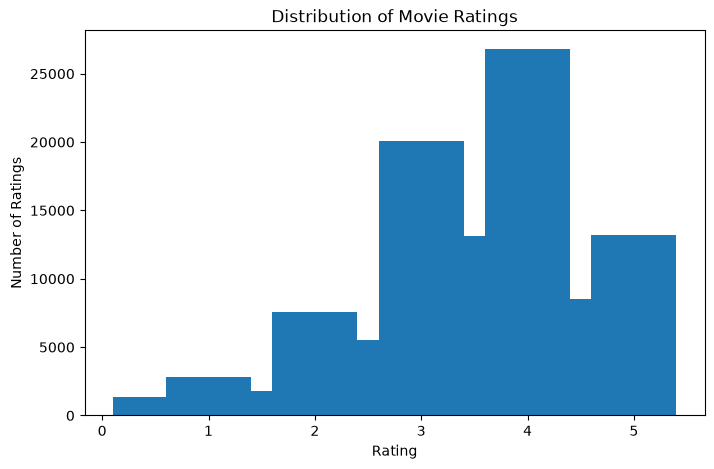

In [52]:
import matplotlib.pyplot as plt

rating_counts = ratings["rating"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(
    rating_counts.index,
    rating_counts.values
)
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.title("Distribution of Movie Ratings")
plt.show()

### 10.2 Average Rating

In [53]:
average_rating = ratings["rating"].mean()

print(f"Average rating: {average_rating:.2f}")

Average rating: 3.50


### 10.3 User Rating Activity

The number of ratings submitted by each user is analyzed to understand how actively users interact with the dataset.

In [54]:
ratings_per_user = (
    ratings.groupby("userId")
    .size()
    .sort_values(ascending=False)
)

ratings_per_user.head(10)

userId
414    2698
599    2478
474    2108
448    1864
274    1346
610    1302
68     1260
380    1218
606    1115
288    1055
dtype: int64

## 11. Movie Genre Analysis

Genres provide content-related information about movies.

Since a movie can belong to multiple genres, the genre values are separated using the `|` delimiter and analyzed individually.

In [55]:
genre_counts = (
    movies["genres"]
    .str.split("|")
    .explode()
    .value_counts()
)

genre_counts

genres
Drama                 4361
Comedy                3756
Thriller              1894
Action                1828
Romance               1596
Adventure             1263
Crime                 1199
Sci-Fi                 980
Horror                 978
Fantasy                779
Children               664
Animation              611
Mystery                573
Documentary            440
War                    382
Musical                334
Western                167
IMAX                   158
Film-Noir               87
(no genres listed)      34
Name: count, dtype: int64

### 11.1 Genre Distribution

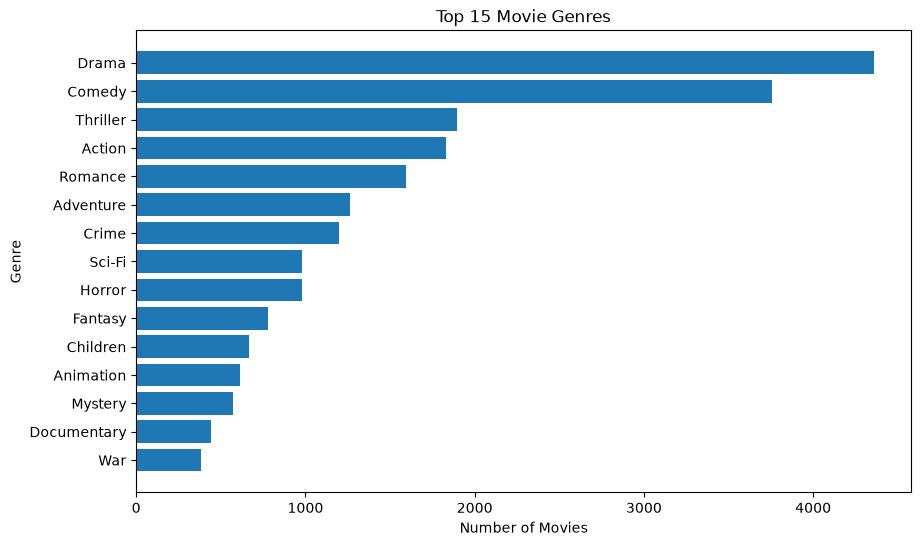

In [56]:
top_genres = genre_counts.head(15)

plt.figure(figsize=(10, 6))
plt.barh(
    top_genres.index[::-1],
    top_genres.values[::-1]
)
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.title("Top 15 Movie Genres")
plt.show()

In [57]:
print(
    "Most common genre:",
    genre_counts.index[0]
)

print(
    "Number of movies:",
    genre_counts.iloc[0]
)

Most common genre: Drama
Number of movies: 4361


## 12. Movie Rating Statistics

Movie-level rating statistics are calculated to identify movies with high user engagement.

Two important measures are considered:

- **Rating count:** Number of users who rated the movie.
- **Average rating:** Mean rating received by the movie.

In [58]:
movie_stats = (
    ratings.groupby("movieId")["rating"]
    .agg(
        average_rating="mean",
        rating_count="count"
    )
    .reset_index()
)

movie_stats = movie_stats.merge(
    movies,
    on="movieId",
    how="left"
)

movie_stats.head()

,movieId,average_rating,rating_count,title,genres
0,1,3.920930,215,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,3.431818,110,Jumanji (1995),Adventure|Children|Fantasy
2,3,3.259615,52,Grumpier Old Men (1995),Comedy|Romance
3,4,2.357143,7,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,3.071429,49,Father of the Bride Part II (1995),Comedy


In [59]:
most_rated = movie_stats.sort_values(
    "rating_count",
    ascending=False
)

most_rated[
    ["movieId", "title", "rating_count", "average_rating"]
].head(10)

,movieId,title,rating_count,average_rating
314,356,Forrest Gump (1994),329,4.164134
277,318,"Shawshank Redemption, The (1994)",317,4.429022
257,296,Pulp Fiction (1994),307,4.197068
510,593,"Silence of the Lambs, The (1991)",279,4.161290
1938,2571,"Matrix, The (1999)",278,4.192446
224,260,Star Wars: Episode IV - A New Hope (1977),251,4.231076
418,480,Jurassic Park (1993),238,3.750000
97,110,Braveheart (1995),237,4.031646
507,589,Terminator 2: Judgment Day (1991),224,3.970982
461,527,Schindler's List (1993),220,4.225000


## 13. Highly Rated Movies

Movies with very few ratings may have unreliable average ratings.

To obtain more meaningful results, movies with a minimum number of ratings are considered when identifying highly rated movies.

In [60]:
highly_rated = movie_stats[
    movie_stats["rating_count"] >= 50
].sort_values(
    "average_rating",
    ascending=False
)

highly_rated[
    ["title", "average_rating", "rating_count"]
].head(10)

,title,average_rating,rating_count
277,"Shawshank Redemption, The (1994)",4.429022,317
659,"Godfather, The (1972)",4.289062,192
2224,Fight Club (1999),4.272936,218
974,Cool Hand Luke (1967),4.271930,57
602,Dr. Strangelove or: How I Learned to Stop Worr...,4.268041,97
686,Rear Window (1954),4.261905,84
921,"Godfather: Part II, The (1974)",4.259690,129
6298,"Departed, The (2006)",4.252336,107
913,Goodfellas (1990),4.250000,126
694,Casablanca (1942),4.240000,100


## 14. User Activity Analysis

The number of ratings submitted by each user is analyzed to understand the distribution of user activity.

This is useful for identifying highly active users and understanding the sparsity of the user-movie interaction data.

In [61]:
user_activity = (
    ratings.groupby("userId")
    .size()
    .reset_index(name="rating_count")
)

user_activity.describe()

,userId,rating_count
count,610.000000,610.000000
mean,305.500000,165.304918
std,176.236111,269.480584
min,1.000000,20.000000
25%,153.250000,35.000000
50%,305.500000,70.500000
75%,457.750000,168.000000
max,610.000000,2698.000000


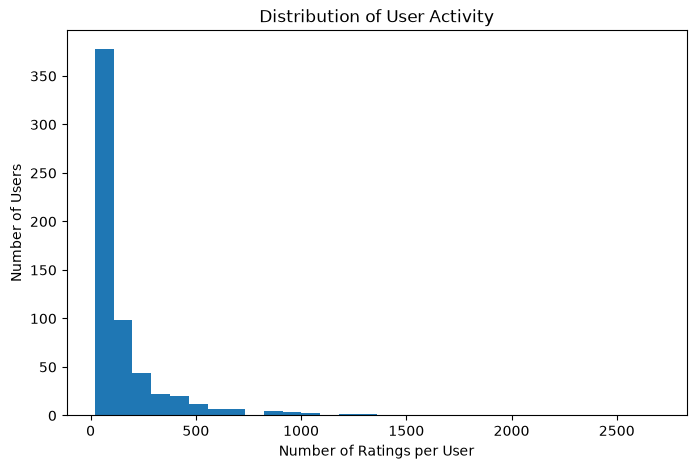

In [62]:
plt.figure(figsize=(8, 5))

plt.hist(
    user_activity["rating_count"],
    bins=30
)

plt.xlabel("Number of Ratings per User")
plt.ylabel("Number of Users")
plt.title("Distribution of User Activity")
plt.show()

## 15. Feature Engineering

Feature engineering transforms the raw dataset into useful attributes that can be used by subsequent recommendation models.

The first feature extracted is the movie's release year, which is available within the movie title.

In [63]:
movies["year"] = movies["title"].str.extract(
    r"\((\d{4})\)"
)

movies["year"] = pd.to_numeric(
    movies["year"],
    errors="coerce"
)

movies[["title", "year"]].head(10)

,title,year
0,Toy Story (1995),1995.0
1,Jumanji (1995),1995.0
2,Grumpier Old Men (1995),1995.0
3,Waiting to Exhale (1995),1995.0
4,Father of the Bride Part II (1995),1995.0
5,Heat (1995),1995.0
6,Sabrina (1995),1995.0
7,Tom and Huck (1995),1995.0
8,Sudden Death (1995),1995.0
9,GoldenEye (1995),1995.0


In [64]:
print("Missing release years:", movies["year"].isnull().sum())

Missing release years: 13


## 16. Genre Feature Engineering

The original `genres` column contains multiple genres separated by `|`.

To make the genre information easier to use in machine learning models, each genre is converted into a separate binary feature.

A value of `1` indicates that the movie belongs to that genre, while `0` indicates that it does not.

In [65]:
genre_features = movies["genres"].str.get_dummies(sep="|")

genre_features.head()

,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,0,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [66]:
print("Genre feature shape:", genre_features.shape)

Genre feature shape: (9742, 20)


## 17. Creating the Processed Movie Dataset

The movie information, release year, genre features, and rating statistics are combined into a single processed dataset.

This dataset will serve as an input to the recommendation model developed in the next stage of the project.

In [67]:
movie_features = movies[
    ["movieId", "title", "year"]
].copy()

movie_features = pd.concat(
    [
        movie_features.reset_index(drop=True),
        genre_features.reset_index(drop=True)
    ],
    axis=1
)

movie_features = movie_features.merge(
    movie_stats[
        ["movieId", "average_rating", "rating_count"]
    ],
    on="movieId",
    how="left"
)

movie_features.head()

,movieId,title,year,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,...,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,average_rating,rating_count
0,1,Toy Story (1995),1995.0,0,0,1,1,1,1,0,...,0,0,0,0,0,0,0,0,3.920930,215.0
1,2,Jumanji (1995),1995.0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,3.431818,110.0
2,3,Grumpier Old Men (1995),1995.0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,3.259615,52.0
3,4,Waiting to Exhale (1995),1995.0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,2.357143,7.0
4,5,Father of the Bride Part II (1995),1995.0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,3.071429,49.0


In [68]:
movie_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   movieId             9742 non-null   int64  
 1   title               9742 non-null   str    
 2   year                9729 non-null   float64
 3   (no genres listed)  9742 non-null   int64  
 4   Action              9742 non-null   int64  
 5   Adventure           9742 non-null   int64  
 6   Animation           9742 non-null   int64  
 7   Children            9742 non-null   int64  
 8   Comedy              9742 non-null   int64  
 9   Crime               9742 non-null   int64  
 10  Documentary         9742 non-null   int64  
 11  Drama               9742 non-null   int64  
 12  Fantasy             9742 non-null   int64  
 13  Film-Noir           9742 non-null   int64  
 14  Horror              9742 non-null   int64  
 15  IMAX                9742 non-null   int64  
 16  Musical          

## 18. Handling Missing Values in Processed Features

Some movies may not have any corresponding ratings or may have missing release-year information.

Missing numerical rating statistics are replaced with zero where appropriate, while missing release years are retained as missing because they represent unavailable information rather than a meaningful zero value.

In [69]:
movie_features["average_rating"] = (
    movie_features["average_rating"].fillna(0)
)

movie_features["rating_count"] = (
    movie_features["rating_count"].fillna(0)
)

In [70]:
movie_features.isnull().sum()

movieId                0
title                  0
year                  13
(no genres listed)     0
Action                 0
Adventure              0
Animation              0
Children               0
Comedy                 0
Crime                  0
Documentary            0
Drama                  0
Fantasy                0
Film-Noir              0
Horror                 0
IMAX                   0
Musical                0
Mystery                0
Romance                0
Sci-Fi                 0
Thriller               0
War                    0
Western                0
average_rating         0
rating_count           0
dtype: int64

## 19. Saving Processed Data

The processed movie-level features are saved separately from the raw dataset.

Keeping raw and processed data separate ensures that the original dataset remains unchanged and allows the processed data to be directly used during model development.

In [71]:
import os

os.makedirs("../data/processed", exist_ok=True)

movie_features.to_csv(
    "../data/processed/movie_features.csv",
    index=False
)

print("Processed movie dataset saved successfully.")

Processed movie dataset saved successfully.


### 19.1 Saving the Ratings Dataset

The ratings dataset is saved separately so that the model-development stage can directly access user-movie interaction data.

In [72]:
ratings.to_csv(
    "../data/processed/ratings_processed.csv",
    index=False
)

print("Processed ratings dataset saved successfully.")

Processed ratings dataset saved successfully.


## 20. Final Dataset Verification

The processed datasets are loaded again to verify that they were saved correctly and can be accessed by the subsequent model-development stage.

In [73]:
processed_movies = pd.read_csv(
    "../data/processed/movie_features.csv"
)

processed_ratings = pd.read_csv(
    "../data/processed/ratings_processed.csv"
)

print(
    "Processed movie features:",
    processed_movies.shape
)

print(
    "Processed ratings:",
    processed_ratings.shape
)

Processed movie features: (9742, 25)
Processed ratings: (100836, 4)


In [74]:
processed_movies.head()

,movieId,title,year,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,...,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,average_rating,rating_count
0,1,Toy Story (1995),1995.0,0,0,1,1,1,1,0,...,0,0,0,0,0,0,0,0,3.920930,215.0
1,2,Jumanji (1995),1995.0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,3.431818,110.0
2,3,Grumpier Old Men (1995),1995.0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,3.259615,52.0
3,4,Waiting to Exhale (1995),1995.0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,2.357143,7.0
4,5,Father of the Bride Part II (1995),1995.0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,3.071429,49.0


## 21. Summary

The MovieLens dataset was successfully explored, validated, and prepared for subsequent recommendation model development.

### Data Handling
- Loaded the Movies, Ratings, Tags, and Links datasets.
- Examined dataset dimensions, structures, and data types.
- Checked for missing values and duplicate records.
- Validated the rating range.

### Exploratory Data Analysis
- Analyzed the distribution of user ratings.
- Examined user rating activity.
- Analyzed movie genre frequencies.
- Identified highly rated and frequently rated movies.
- Calculated movie-level rating statistics.

### Feature Engineering
- Extracted movie release years.
- Converted movie genres into individual binary features.
- Calculated average movie ratings and rating counts.
- Combined movie metadata and rating statistics into a processed feature dataset.

### Output

The following processed datasets were generated:

- `movie_features.csv`
- `ratings_processed.csv`

These datasets are prepared to be used by the recommendation-model development stage.